<a href="https://colab.research.google.com/github/ThiagoBrandaorj/Deep_learning/blob/main/C%C3%B3pia_de_AP2_Deep_Learning__.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AP2 - Predição de Consumo de Energia com Deep Learning

**Isabella Vieira, Thiago Brandão, João Pedro Menezes, Fabiano Amorim, Breno França**


**Dataset:** Appliances Energy Prediction (UCI, id=374)  
**Objetivo:** prever o consumo médio horário de `Appliances` (Wh) usando janelas temporais de **48 horas**.

O experimento compara duas arquiteturas recorrentes, **GRU** e **LSTM**, mantendo as mesmas condições de treino para uma comparação justa. O critério de seleção final é o menor **MAE no conjunto de teste**.


#Introdução

## Descrição das Variáveis

- **`date`** - Data e hora (ano-mês-dia hora:minuto:segundo)

- **`Appliances`** - Consumo de energia dos eletrodomésticos (Wh) 🎯 *target*

- **`lights`** - Consumo das lâmpadas (Wh)

- **Temperatura (`T`) e Umidade (`RH`)** por cômodo:
  - `1`: Cozinha
  - `2`: Sala de estar
  - `3`: Lavanderia
  - `4`: Escritório
  - `5`: Banheiro
  - `6`: Exterior (norte do prédio)
  - `7`: Sala de passar roupa
  - `8`: Quarto do adolescente 2
  - `9`: Quarto dos pais

- **Meteorologia (Estação Chievres):**
  - `To` - Temperatura externa (°C)
  - `Pressure` - Pressão (mm Hg)
  - `RH_out` - Umidade externa (%)
  - `Wind speed` - Vento (m/s)
  - `Visibility` - Visibilidade (km)
  - `Tdewpoint` - Ponto de orvalho (°C)

- **Controle:** `rv1`, `rv2` - variáveis aleatórias (ruído adicionado)

> Os dados meteorológicos são horários interpolados para 10 min. Fonte: Reliable Prognosis (rp5.ru), com permissão para distribuição.

### Cuidados metodológicos

Para garantir a consistência da modelagem e evitar vazamento de informação entre as etapas de treinamento e avaliação, alguns cuidados metodológicos foram adotados ao longo do desenvolvimento do trabalho.

Inicialmente, a divisão dos dados respeitou estritamente a ordem temporal da série, sem qualquer tipo de embaralhamento. Essa escolha é fundamental em problemas de previsão temporal, uma vez que o modelo deve aprender a partir de informações passadas para estimar valores futuros, reproduzindo de forma mais fiel o cenário real de uso.

Além disso, a padronização das variáveis foi realizada com o `StandardScaler` ajustado exclusivamente sobre o conjunto de treino. Em seguida, os mesmos parâmetros de escala foram aplicados aos conjuntos de validação e teste. Esse procedimento evita que informações dos dados futuros influenciem o processo de treinamento, preservando a integridade da avaliação.

As variáveis defasadas e as médias móveis também foram construídas apenas com base em valores anteriores da série, por meio de operações retrospectivas como `shift` e `rolling`. Dessa forma, assegura-se que nenhuma informação futura seja utilizada no momento da previsão.

A estratégia adotada neste trabalho corresponde a uma previsão *one-step-ahead*, na qual o modelo utiliza o histórico das últimas 48 horas para estimar o consumo da hora seguinte. Assim, a arquitetura é treinada para capturar padrões recentes da série temporal e projetar o comportamento imediatamente posterior.

O conjunto de teste foi reservado exclusivamente para a avaliação final do modelo, não sendo utilizado no ajuste de hiperparâmetros ou na escolha das configurações da arquitetura. Essa separação permite uma análise mais realista da capacidade de generalização do modelo diante de dados ainda não observados.

Por fim, ressalta-se que o escopo do trabalho foi delimitado ao uso de modelos de *Deep Learning*, em conformidade com os objetivos da disciplina e com a proposta de investigar arquiteturas neurais aplicadas à previsão de séries temporais.


# 1. EDA

Importando bibliotecas necessárias

In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("ucimlrepo") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ucimlrepo"])


In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


Buscando o dataset, que vem separado inicialmente entre variáveis independentes e dependentes, porém iremos agregar tudo em um único dataset.

In [ ]:
# Busca do dataset na UCI Machine Learning Repository.
appliances_energy_prediction = fetch_ucirepo(id=374)

X = appliances_energy_prediction.data.features
y = appliances_energy_prediction.data.targets

df = pd.concat([X.copy(), y.copy()], axis=1)

print(f"Linhas e colunas: {df.shape}")
print(f"Duplicatas: {df.duplicated().sum()}")
print(f"Valores nulos: {df.isna().sum().sum()}")
display(df.head())


Linhas e colunas: (19735, 29)
Duplicatas: 0
Valores nulos: 0


,date,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Appliances
0,2016-01-1117:00:00,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,60
1,2016-01-1117:10:00,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,60
2,2016-01-1117:20:00,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,50
3,2016-01-1117:30:00,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390,50
4,2016-01-1117:40:00,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,60


Vemos que não há valores nulos nem duplicados.

Nesta etapa, a coluna date foi tratada e convertida para o formato datetime, garantindo que a série pudesse ser organizada corretamente no tempo. O código remove espaços, caracteres invisíveis e corrige possíveis registros em que data e hora aparecem sem separação.

In [ ]:
df = pd.concat([X.copy(), y.copy()], axis=1)
df["date_original"] = df["date"].astype(str)

# Remove caracteres de controle e espaços extras.
df["date"] = (
    df["date"]
    .astype(str)
    .str.strip()
    .str.replace(r"[\x00-\x1F\x7F-\x9F]", "", regex=True)
)


In [ ]:
# Alguns registros podem ter a data colada com a hora sem espaço separador.
mask_sem_espaco = df["date"].str.match(
    r"^\d{4}-\d{2}-\d{2}\d{2}:\d{2}:\d{2}$", na=False
)

df.loc[mask_sem_espaco, "date"] = df.loc[mask_sem_espaco, "date"].str.replace(
    r"^(\d{4}-\d{2}-\d{2})(\d{2}:\d{2}:\d{2})$",
    lambda m: f"{m.group(1)} {m.group(2)}",
    regex=True,
)


In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

datas_invalidas = df["date"].isna().sum()
if datas_invalidas > 0:
    print(f"Foram encontradas {datas_invalidas} datas inválidas.")
    display(df.loc[df["date"].isna(), ["date_original"]].head(10))
    raise ValueError("Existem datas inválidas. Verifique os exemplos acima.")


In [ ]:
df = df.drop(columns=["date_original"])
df = df.set_index("date").sort_index()

print(f"Início da série: {df.index.min()}")
print(f"Fim da série:    {df.index.max()}")
print(f"Número de dias:  {df.index.normalize().nunique()}")
display(df.head())


Início da série: 2016-01-11 17:00:00
Fim da série:    2016-05-27 18:00:00
Número de dias:  138


,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Appliances
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,...,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,60
2016-01-11 17:10:00,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,...,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,60
2016-01-11 17:20:00,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,...,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,50
2016-01-11 17:30:00,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,...,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390,50
2016-01-11 17:40:00,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,...,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,60


Como não foram encontradas datas inválidas, a base ficou temporalmente consistente para as próximas etapas. Esse cuidado é essencial porque os modelos GRU e LSTM dependem da ordem cronológica correta para aprender o histórico de consumo e prever a hora seguinte.

A EDA é estruturada em quatro blocos:

1. **Visualização da série bruta**, identificação de picos e ruídos na resolução de 10 minutos.
2. **Padrão diário médio**, consumo médio por hora do dia, revelando o ritmo circadiano.
3. **Análise de correlação serial (ACF/PACF)**, quanta memória temporal a série possui.
4. **Decomposição sazonal e teste de estacionaridade**, verificação formal de tendência, sazonalidade e raiz unitária.


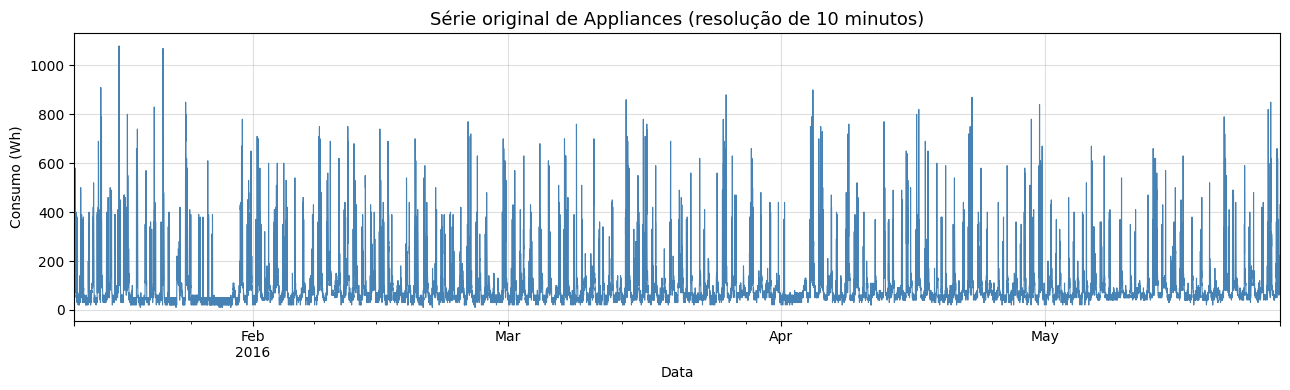

In [ ]:
# série bruta
fig, ax = plt.subplots(figsize=(13, 4))
df["Appliances"].plot(ax=ax, linewidth=0.8, color="steelblue")
ax.set_title("Série original de Appliances (resolução de 10 minutos)", fontsize=13)
ax.set_ylabel("Consumo (Wh)")
ax.set_xlabel("Data")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


A série original de Appliances, ainda na frequência de 10 minutos, apresenta forte oscilação ao longo do tempo, com muitos picos de consumo concentrados em períodos curtos. Isso indica que o consumo residencial não segue um comportamento totalmente regular, sendo influenciado por eventos pontuais de uso dos equipamentos. Por esse motivo, trabalhar diretamente na resolução de 10 minutos poderia aumentar o ruído da modelagem. A agregação para médias horárias é uma escolha adequada, pois suaviza parte dessas variações extremas sem perder o padrão temporal principal da série.

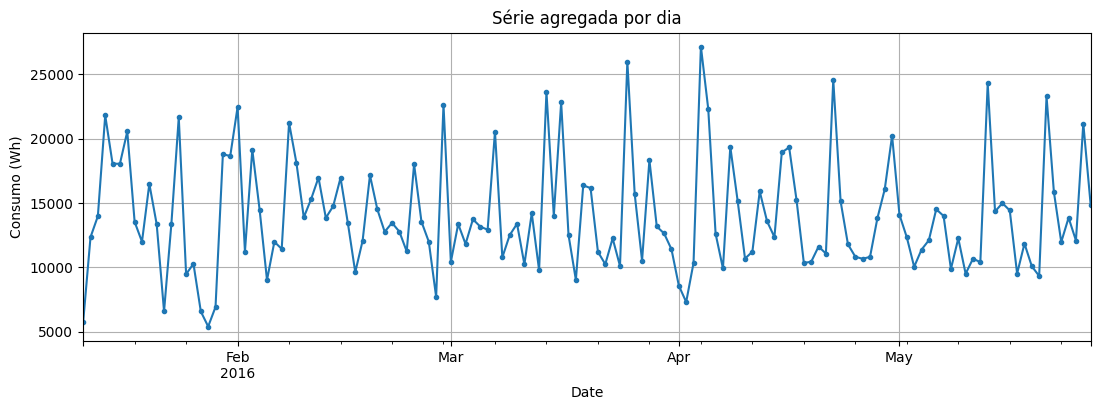

In [ ]:
daily_appliances_consumption = df['Appliances'].resample('D').sum()

plt.figure(figsize=(13, 4))
daily_appliances_consumption.plot(grid=True, marker='.')
plt.ylabel('Consumo (Wh)')
plt.title('Série agregada por dia')
plt.xlabel('Date')
plt.show()

No gráfico acima visualizamos o consumo de energia da casa por dia, existem 138 dias no dataset. Olhando apenas para o consumo por dia não é possível notar alguma sazionalidade muito transparente.

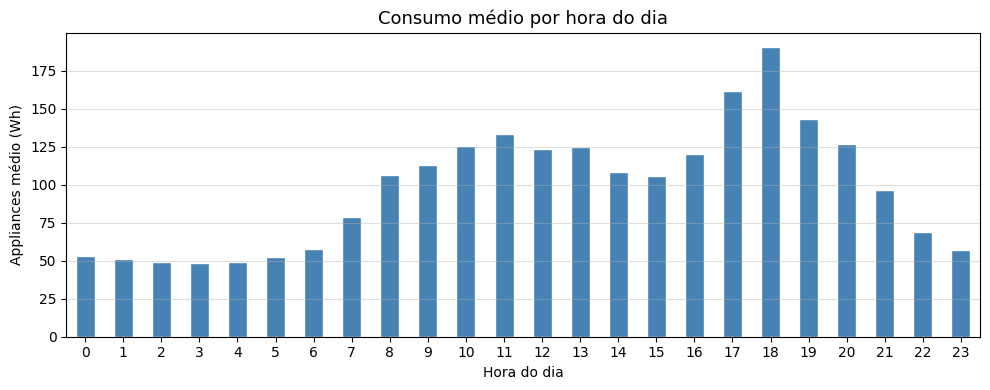

In [ ]:
#Padrão médio por hora do dia
df_eda = df.copy()
df_eda["hour"] = df_eda.index.hour
consumo_por_hora = df_eda.groupby("hour")["Appliances"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
consumo_por_hora.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Consumo médio por hora do dia", fontsize=13)
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Appliances médio (Wh)")
ax.tick_params(axis="x", rotation=0)
ax.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


O gráfico apresenta o consumo médio de energia por hora do dia, considerando todas as observações ao longo dos 138 dias da série. É possível observar um padrão diário bem definido: o consumo permanece mais baixo durante a madrugada, começa a aumentar a partir das 7h e se mantém elevado durante a manhã e início da tarde.

Após uma leve redução no meio da tarde, o consumo volta a crescer a partir das 16h, atingindo seu pico por volta das 18h. Esse comportamento pode estar associado ao aumento da atividade doméstica no fim do dia, como maior uso de eletrodomésticos e iluminação. Depois desse horário, o consumo diminui gradualmente até o final da noite, aproximando-se novamente dos níveis observados na madrugada.

Dessa forma, o gráfico evidencia uma sazonalidade diária no consumo de energia, diretamente relacionada à hora do dia. Esse resultado confirma que a variável temporal é relevante para a previsão e justifica a criação de features cíclicas, como hour_sin e hour_cos, nas etapas seguintes da modelagem.

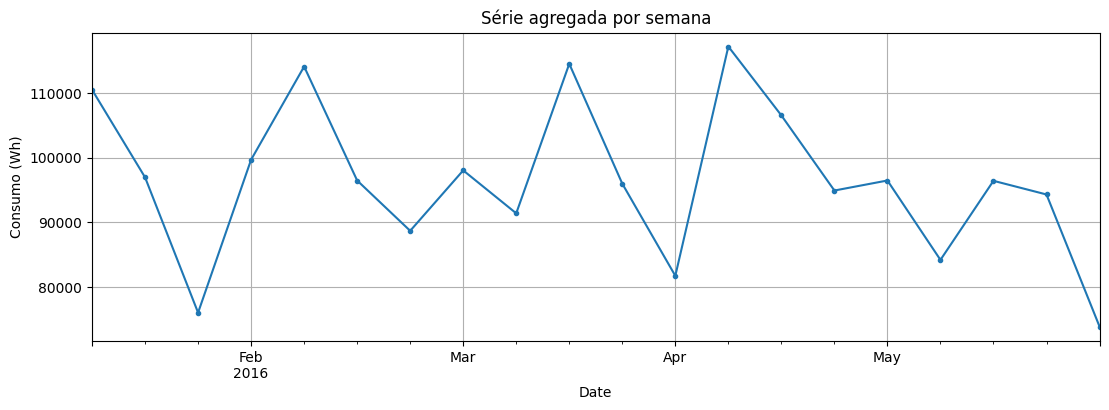

In [ ]:
weekly_appliances_consumption = df['Appliances'].resample('W').sum()

plt.figure(figsize=(13, 4))
weekly_appliances_consumption.plot(grid=True, marker='.')
plt.ylabel('Consumo (Wh)')
plt.title('Série agregada por semana')
plt.xlabel('Date')
plt.show()

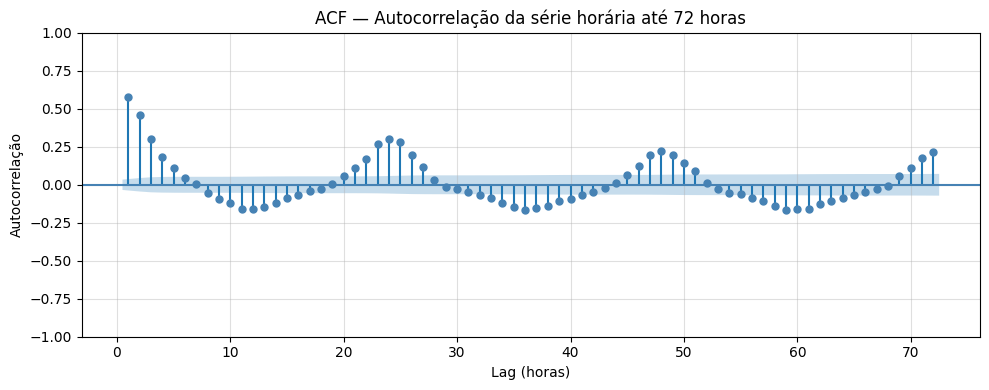

In [ ]:
# ACF da série horária
# A série foi agregada para frequência horária antes da análise.
serie_horaria = df["Appliances"].resample("h").mean().dropna()

from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))

plot_acf(serie_horaria, lags=72, ax=ax, color="steelblue", zero=False)
ax.set_title("ACF — Autocorrelação da série horária até 72 horas", fontsize=12)
ax.set_xlabel("Lag (horas)")
ax.set_ylabel("Autocorrelação")
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

A ACF foi utilizada para analisar a autocorrelação da série horária, ou seja, o quanto o consumo atual se relaciona com valores passados. O gráfico mostra correlações relevantes nas primeiras horas e sinais de repetição em torno de múltiplos de 24 horas, indicando presença de memória temporal e sazonalidade diária.

Esse resultado ajuda a justificar o uso de modelos recorrentes e a escolha da janela de 48 horas, pois ela permite que o modelo observe dois ciclos diários completos antes de prever o consumo da hora seguinte.

**Esses resultados justificam o uso de modelos recorrentes, como GRU e LSTM, e sustentam a escolha da janela de 48 horas, suficiente para capturar dois ciclos diários completos.**

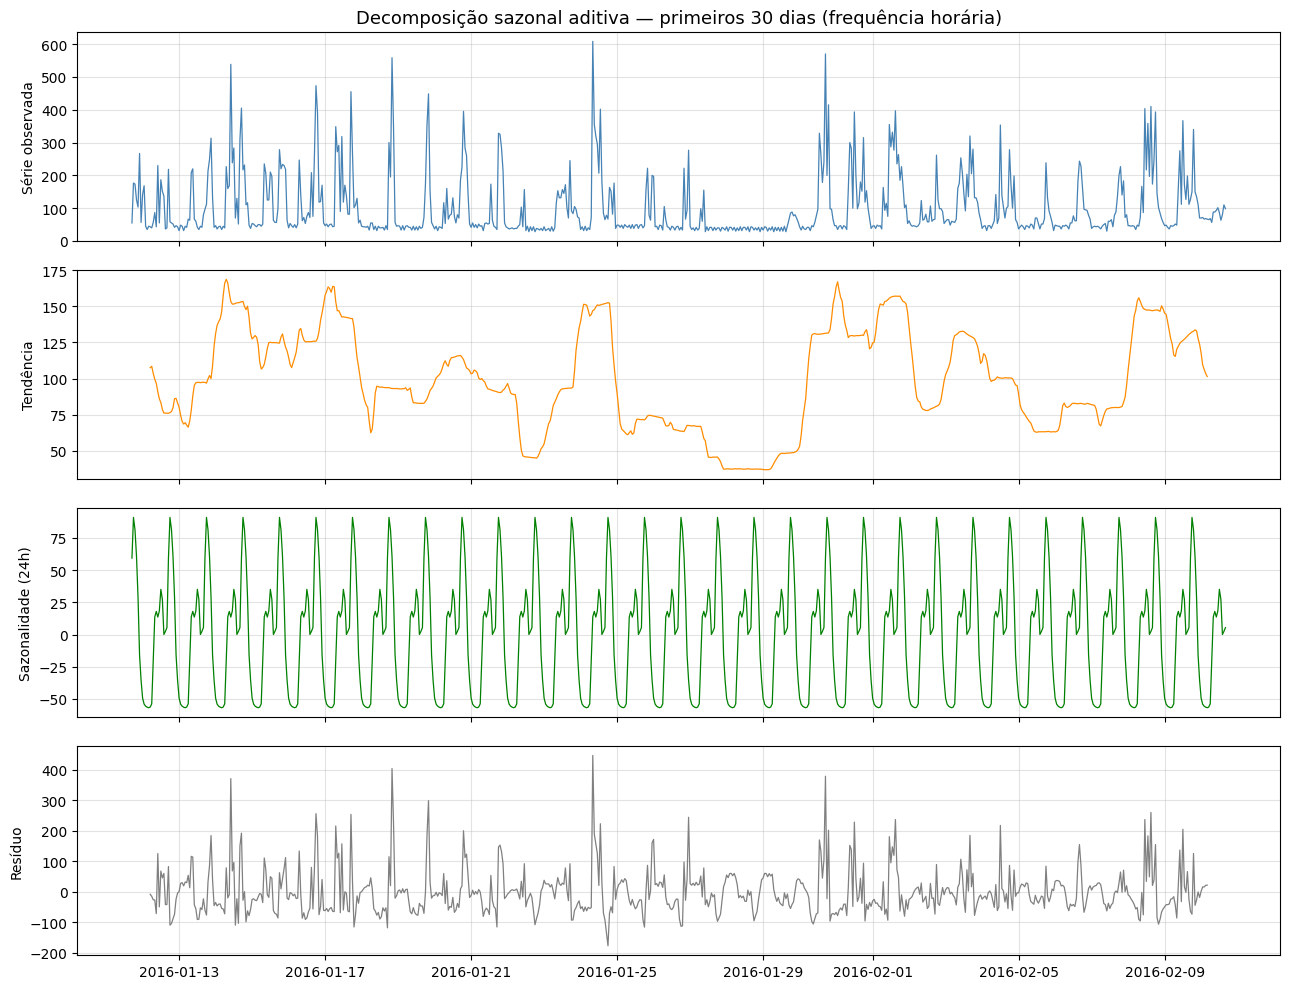

In [ ]:
# Decomposição sazonal
from statsmodels.tsa.seasonal import seasonal_decompose

# Usamos os primeiros 30 dias para a decomposição visual (mais legível).
serie_30d = serie_horaria.iloc[:30 * 24]

decomp = seasonal_decompose(serie_30d, model="additive", period=24)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
componentes = [
    (decomp.observed,  "Série observada",    "steelblue"),
    (decomp.trend,     "Tendência",          "darkorange"),
    (decomp.seasonal,  "Sazonalidade (24h)", "green"),
    (decomp.resid,     "Resíduo",            "gray"),
]
for ax, (serie, titulo, cor) in zip(axes, componentes):
    ax.plot(serie, color=cor, linewidth=0.9)
    ax.set_ylabel(titulo, fontsize=10)
    ax.grid(True, alpha=0.35)

axes[0].set_title("Decomposição sazonal aditiva — primeiros 30 dias (frequência horária)", fontsize=13)
plt.tight_layout()
plt.show()


A decomposição separa a série em três partes:

- **Tendência:** variação de longo prazo no nível médio do consumo.
- **Sazonalidade:** padrão repetitivo de 24 horas (um ciclo por dia).
- **Resíduo:** o que sobra após remover tendência e sazonalidade, quanto mais aleatório, melhor o ajuste do modelo sazonal.

A decomposição confirma que a série horária possui um certo padrão, com repetição aproximada a cada 24 horas. A tendência varia ao longo dos dias, mostrando mudanças no nível médio de consumo, enquanto os resíduos ainda apresentam picos expressivos. Isso indica que, **embora exista um padrão temporal aprendível, parte do consumo depende de eventos irregulares, o que pode dificultar a previsão de valores extremos.**


In [ ]:
# Teste de estacionaridade (ADF)
from statsmodels.tsa.stattools import adfuller

adf_stat, adf_p, _, _, adf_crit, _ = adfuller(serie_horaria.dropna(), autolag="AIC")

print("=" * 55)
print("Teste ADF (Augmented Dickey-Fuller)")
print(f"  Estatística: {adf_stat:.4f}")
print(f"  p-valor:     {adf_p:.4f}")
print(f"  Valores críticos: {adf_crit}")

conclusao_adf = (
    "Série ESTACIONÁRIA (rejeita H0)"
    if adf_p < 0.05
    else "Série NÃO estacionária (não rejeita H0)"
)

print(f"  Conclusão: {conclusao_adf}")
print("=" * 55)

Teste ADF (Augmented Dickey-Fuller)
  Estatística: -8.9489
  p-valor:     0.0000
  Valores críticos: {'1%': np.float64(-3.432357502010421), '5%': np.float64(-2.862426994644342), '10%': np.float64(-2.567242166152283)}
  Conclusão: Série ESTACIONÁRIA (rejeita H0)


A estacionaridade da série foi analisada por meio do teste ADF. Nesse teste, a hipótese nula indica que a série não é estacionária.

**Como o p-valor foi inferior a 0,05, rejeita-se essa hipótese, sugerindo que a série horária pode ser considerada estacionária.** Na prática, isso indica que não há necessidade evidente de aplicar diferenciação antes da modelagem, permitindo utilizar a série diretamente nos modelos recorrentes e preservar seus padrões originais de nível, sazonalidade e variação.


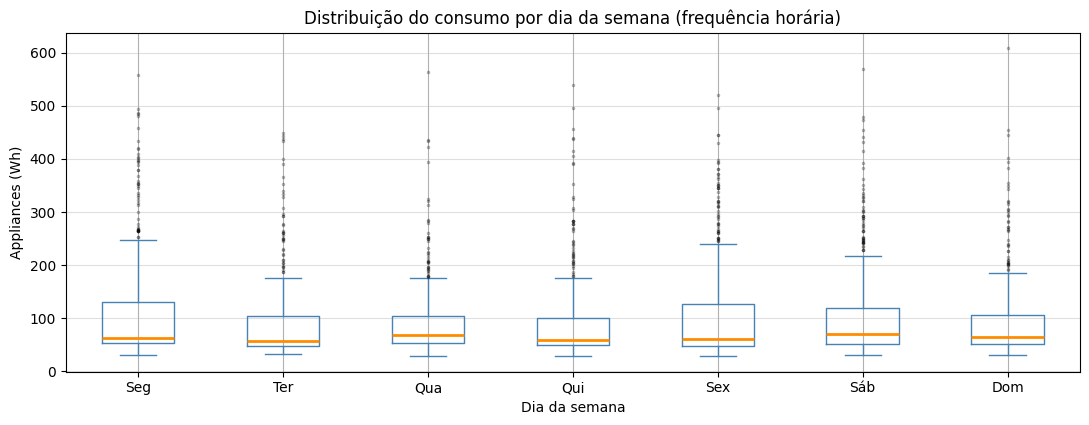

In [ ]:
# Boxplot por dia da semana
df_eda_h = serie_horaria.to_frame(name="Appliances")
df_eda_h["dia_semana"] = df_eda_h.index.day_name()

ordem_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
nomes_pt   = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

df_eda_h["dia_semana"] = pd.Categorical(df_eda_h["dia_semana"], categories=ordem_dias, ordered=True)

fig, ax = plt.subplots(figsize=(11, 4.5))
df_eda_h.boxplot(column="Appliances", by="dia_semana", ax=ax,
                 boxprops=dict(color="steelblue"),
                 medianprops=dict(color="darkorange", linewidth=2),
                 whiskerprops=dict(color="steelblue"),
                 capprops=dict(color="steelblue"),
                 flierprops=dict(marker=".", markersize=3, alpha=0.3))
ax.set_xticklabels(nomes_pt)
ax.set_title("Distribuição do consumo por dia da semana (frequência horária)", fontsize=12)
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Appliances (Wh)")
plt.suptitle("")
ax.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.show()


O boxplot por dia da semana mostra que a distribuição do consumo varia entre os dias, com presença de outliers em praticamente toda a semana. Isso sugere que o comportamento de consumo não depende apenas da hora do dia, mas também pode mudar conforme o dia da semana. **Essa evidência justifica a inclusão de variáveis cíclicas semanais, como dow_sin e dow_cos, permitindo que os modelos capturem possíveis diferenças entre dias úteis e finais de semana.**

# 2. Pré-Processamento

## 4. Base horária e Feature Engineering

A base foi convertida da frequência de 10 minutos para médias horárias. Essa decisão reduz parte do ruído de curtíssimo prazo observado na série original, mantendo o padrão temporal mais relevante para a previsão. Com isso, o modelo passa a aprender o comportamento médio por hora, e não oscilações muito pontuais.

- **Features cíclicas de calendário** (`hour_sin/cos`, `dow_sin/cos`): representam hora do dia e dia da semana de forma contínua, sem o salto artificial de 23 → 0 ou 6 → 0.
- **Lags retrospectivos**: consumo 24h e 168h (1 semana) atrás capturam padrões diários e semanais.
- **Médias móveis**: média das últimas 3h e 24h suavizam ruídos e indicam tendência recente.

As colunas `rv1` e `rv2` são variáveis aleatórias incluídas originalmente como ruído de controle e são removidas por não terem valor preditivo.


In [ ]:
def criar_base_horaria_com_features(df_original):
    """Agrega em frequência horária e cria features temporais retrospectivas."""
    df_h = df_original.resample("h").mean().asfreq("h")

    # Remove variáveis aleatórias e colunas auxiliares da EDA.
    cols_drop = [c for c in ["rv1", "rv2", "hour"] if c in df_h.columns]
    df_h = df_h.drop(columns=cols_drop)

    # Features cíclicas de calendário (sem discontinuidade numérica).
    df_h["hour_sin"] = np.sin(2 * np.pi * df_h.index.hour / 24)
    df_h["hour_cos"] = np.cos(2 * np.pi * df_h.index.hour / 24)
    df_h["dow_sin"]  = np.sin(2 * np.pi * df_h.index.dayofweek / 7)
    df_h["dow_cos"]  = np.cos(2 * np.pi * df_h.index.dayofweek / 7)

    # Lags retrospectivos do alvo (apenas passado).
    df_h["lag_24h"]  = df_h["Appliances"].shift(24)
    df_h["lag_168h"] = df_h["Appliances"].shift(168)

    # Médias móveis retrospectivas.
    df_h["roll_3h"]  = df_h["Appliances"].rolling(3).mean()
    df_h["roll_24h"] = df_h["Appliances"].rolling(24).mean()

    # Remove linhas iniciais sem histórico suficiente para os lags.
    df_h = df_h.dropna().copy()
    return df_h


In [ ]:
df_hourly = criar_base_horaria_com_features(df)

target_col  = "Appliances"
feature_cols = df_hourly.columns.tolist()
target_idx  = feature_cols.index(target_col)

print(f"Shape da base horária:  {df_hourly.shape}")
print(f"Total de features:      {len(feature_cols)}")
print(f"Período disponível:     {df_hourly.index.min()} → {df_hourly.index.max()}")
display(df_hourly.head())


Shape da base horária:  (3122, 34)
Total de features:      34
Período disponível:     2016-01-18 17:00:00 → 2016-05-27 18:00:00


,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,Tdewpoint,Appliances,hour_sin,hour_cos,dow_sin,dow_cos,lag_24h,lag_168h,roll_3h,roll_24h
date,,,,,,,,,,,,,,,,,,,,,
2016-01-18 17:00:00,0.000000,19.172222,41.175556,17.962222,41.530000,19.500000,40.693889,18.616667,38.084722,17.401111,...,-3.958333,35.000000,-0.965926,-2.588190e-01,0.0,1.0,455.000000,55.000000,38.333333,61.805556
2016-01-18 18:00:00,8.333333,19.100000,41.075556,17.812222,41.527778,19.357222,40.324444,18.457222,38.157222,17.348333,...,-4.358333,300.000000,-1.000000,-1.836970e-16,0.0,1.0,268.333333,176.666667,127.222222,63.125000
2016-01-18 19:00:00,8.333333,19.574444,42.057778,18.263750,42.203889,19.488889,40.265556,18.317778,38.393333,17.413916,...,-5.333333,195.000000,-0.965926,2.588190e-01,0.0,1.0,101.666667,173.333333,176.666667,67.013889
2016-01-18 20:00:00,10.000000,20.258611,41.407083,19.100556,42.037778,20.196667,43.094444,18.611667,38.590972,18.658056,...,-5.675000,558.333333,-0.866025,5.000000e-01,0.0,1.0,110.000000,125.000000,351.111111,85.694444
2016-01-18 21:00:00,11.666667,20.642222,40.164444,19.583788,40.143586,21.028889,45.406667,21.140000,37.362222,18.175202,...,-5.750000,345.000000,-0.707107,7.071068e-01,0.0,1.0,130.000000,103.333333,366.111111,94.652778


**As features cíclicas foram criadas para representar variáveis temporais, como hora do dia e dia da semana, de forma mais adequada para a modelagem. **Em vez de tratar essas variáveis como números lineares, usamos seno e cosseno para preservar sua natureza circular. Isso evita, por exemplo, que 23h e 0h sejam interpretadas como horários muito distantes, quando na prática são horários consecutivos.

Essa abordagem é recomendada para séries temporais com padrões periódicos, pois transforma variáveis cíclicas em coordenadas contínuas, permitindo que o modelo reconheça melhor relações de proximidade dentro do ciclo [1]. No contexto deste trabalho, isso é importante porque a EDA mostrou que o consumo de energia varia de acordo com a hora do dia e pode apresentar diferenças conforme o dia da semana.

Assim, foram criadas as variáveis `hour_sin`, `hour_cos`, `dow_sin` e `dow_cos`, que ajudam o modelo a capturar os ciclos diários e semanais sem introduzir descontinuidades artificiais na base.


## 5. Divisão Treino, Validação, Teste

Os dados são divididos **cronologicamente** em três blocos sem sobreposição.

O teste permanece completamente isolado até a avaliação final.


In [ ]:
# Split fixo e cronológico — sem embaralhamento.
train_df = df_hourly.loc[:"2016-05-13 23:00"].copy()
valid_df = df_hourly.loc["2016-05-14 00:00":"2016-05-20 23:00"].copy()
test_df  = df_hourly.loc["2016-05-21 00:00":"2016-05-27 23:00"].copy()

if len(train_df) == 0 or len(valid_df) == 0 or len(test_df) == 0:
    raise ValueError("Algum split ficou vazio. Verifique as datas do dataset.")

print(f"Treino:    {train_df.index.min()} → {train_df.index.max()} ({len(train_df)} h)")
print(f"Validação: {valid_df.index.min()} → {valid_df.index.max()} ({len(valid_df)} h)")
print(f"Teste:     {test_df.index.min()}  → {test_df.index.max()}  ({len(test_df)} h)")


Treino:    2016-01-18 17:00:00 → 2016-05-13 23:00:00 (2791 h)
Validação: 2016-05-14 00:00:00 → 2016-05-20 23:00:00 (168 h)
Teste:     2016-05-21 00:00:00  → 2016-05-27 18:00:00  (163 h)


## 6. Preparação das janelas temporais

Nesta etapa, a série é transformada em janelas temporais para que os modelos recorrentes consigam aprender a partir do histórico. Cada entrada contém as últimas 48 horas de todas as variáveis, e o alvo corresponde ao consumo de Appliances na hora seguinte, caracterizando uma previsão one-step-ahead.

A validação e o teste recebem um prefixo com as horas imediatamente anteriores ao início de cada conjunto. Isso permite formar as primeiras janelas desses blocos sem misturar os dados de avaliação com o treino de forma indevida. Assim, a sequência temporal é preservada e a avaliação fica mais próxima de um cenário real.

A normalização também é feita de forma cuidadosa: o StandardScaler é ajustado apenas no treino e depois aplicado à validação e ao teste.

In [ ]:
def criar_janelas_multivariadas(array_values, seq_length, target_idx):
    """Converte um array 2D em pares (janela de entrada, próximo valor alvo)."""
    X, y = [], []
    for i in range(len(array_values) - seq_length):
        X.append(array_values[i : i + seq_length, :])
        y.append(array_values[i + seq_length, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


In [ ]:
def montar_bloco_com_contexto(df_completo, bloco_avaliacao, seq_length):
    """Adiciona as horas de histórico necessárias antes do bloco de avaliação."""
    inicio = bloco_avaliacao.index.min()
    prefixo = df_completo.loc[: inicio - pd.Timedelta(hours=1)].tail(seq_length)

    if len(prefixo) < seq_length:
        raise ValueError("Prefixo histórico insuficiente para formar janelas.")

    return pd.concat([prefixo, bloco_avaliacao], axis=0)


In [ ]:
def criar_dataset_tf(X, y, batch_size=32, shuffle=False):
    """Empacota arrays NumPy em tf.data.Dataset com batching e prefetch."""
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


In [ ]:
def preparar_dados_por_janela(seq_length, batch_size=32):
    """Orquestra normalização, criação de janelas e montagem dos datasets."""
    valid_context = montar_bloco_com_contexto(df_hourly, valid_df, seq_length)
    test_context  = montar_bloco_com_contexto(df_hourly, test_df,  seq_length)

    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_df.values)
    valid_scaled = scaler.transform(valid_context.values)
    test_scaled  = scaler.transform(test_context.values)

    X_train, y_train = criar_janelas_multivariadas(train_scaled, seq_length, target_idx)
    X_valid, y_valid = criar_janelas_multivariadas(valid_scaled, seq_length, target_idx)
    X_test,  y_test  = criar_janelas_multivariadas(test_scaled,  seq_length, target_idx)

    return {
        "seq_length":    seq_length,
        "scaler":        scaler,
        "target_mean":   scaler.mean_[target_idx],
        "target_scale":  scaler.scale_[target_idx],
        "X_train": X_train, "y_train": y_train,
        "X_valid": X_valid, "y_valid": y_valid,
        "X_test":  X_test,  "y_test":  y_test,
        "train_ds": criar_dataset_tf(X_train, y_train, batch_size, shuffle=True),
        "valid_ds": criar_dataset_tf(X_valid, y_valid, batch_size),
        "test_ds":  criar_dataset_tf(X_test,  y_test,  batch_size),
        "train_index": train_df.index[seq_length:],
        "valid_index": valid_df.index,
        "test_index":  test_df.index,
        "n_features":  X_train.shape[2],
    }


## 7. Métricas de avaliação

Nesta etapa, foram definidas as métricas usadas para avaliar os modelos: MAE, RMSE, R² e MAPE. As previsões são desnormalizadas para que os erros sejam interpretados na escala real de consumo, em Wh.

O MAE é usado como principal critério por ser direto e fácil de interpretar. O RMSE complementa a análise ao penalizar mais os erros grandes, enquanto o R² indica o quanto da variação da série foi explicada pelo modelo. Já o MAPE mostra o erro médio em termos percentuais.

Essa etapa garante uma comparação padronizada entre treino, validação e teste, permitindo avaliar não só o desempenho final, mas também possíveis diferenças de generalização entre os conjuntos.


In [ ]:
METRICAS_PRINCIPAIS = ["MAE", "RMSE", "R²", "MAPE (%)"]
COLUNAS_RESULTADO   = ["Modelo", "Janela", "Dataset"] + METRICAS_PRINCIPAIS


def desnormalizar_target(y_scaled, target_mean, target_scale):
    return np.asarray(y_scaled).ravel() * target_scale + target_mean


def calcular_mape_seguro(y_real, y_pred, eps=1e-8):
    y_real = np.asarray(y_real).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mask = np.abs(y_real) > eps
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100


def calcular_metricas_arrays(y_real, y_pred, model_name, seq_length, dataset_name):
    y_real = np.asarray(y_real).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mask   = np.isfinite(y_real) & np.isfinite(y_pred)
    y_real, y_pred = y_real[mask], y_pred[mask]

    return {
        "Modelo":    model_name,
        "Janela":    f"{seq_length}h",
        "Dataset":   dataset_name,
        "MAE":       mean_absolute_error(y_real, y_pred),
        "RMSE":      np.sqrt(mean_squared_error(y_real, y_pred)),
        "R²":        r2_score(y_real, y_pred),
        "MAPE (%)":  calcular_mape_seguro(y_real, y_pred),
    }


In [ ]:
def prever_desnormalizado(model, X, target_mean, target_scale):
    y_pred_scaled = model.predict(X, verbose=0).ravel()
    return desnormalizar_target(y_pred_scaled, target_mean, target_scale)


def avaliar_modelo_em_bases(model, dados, model_name):
    resultados = []
    tm, ts, sl = dados["target_mean"], dados["target_scale"], dados["seq_length"]

    for nome_base, X_base, y_base in [
        ("Treino",    dados["X_train"], dados["y_train"]),
        ("Validação", dados["X_valid"], dados["y_valid"]),
        ("Teste",     dados["X_test"],  dados["y_test"]),
    ]:
        y_real = desnormalizar_target(y_base, tm, ts)
        y_pred = prever_desnormalizado(model, X_base, tm, ts)
        resultados.append(
            calcular_metricas_arrays(y_real, y_pred, model_name, sl, nome_base)
        )

    return resultados


# 3. Modelagem

## 3.1 Arquiteturas dos modelos

Ambos os modelos seguem a mesma estrutura geral:

```
Entrada (48 horas × n_features)
    ↓
Camada recorrente (GRU ou LSTM, 64 unidades)
    ↓
Dense (32 neurônios, ReLU) + Dropout
    ↓
Saída (1 valor — consumo da próxima hora)
```

**Hiperparâmetros compartilhados:**
- Otimizador: Adam (lr = 0,001)
- Função de perda: Huber Loss (robusta a outliers)
- Regularização: Dropout (0,25) + L2 (1e-4)
- Parada antecipada: EarlyStopping (patience = 20, monitora `val_mae`)
- Redução de LR: ReduceLROnPlateau (patience = 8, fator = 0,5)


In [ ]:
DROPOUT_RATE  = 0.25
L2_RATE       = 1e-4
LEARNING_RATE = 1e-3
MAX_EPOCHS    = 300
PATIENCE_EARLY = 20
PATIENCE_LR    = 8
BATCH_SIZE    = 32

regularizer = tf.keras.regularizers.l2(L2_RATE)


Huber Loss é uma alternativa mais robusta quando os dados contêm outliers ou variações muito grandes

In [ ]:
def criar_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_mae", patience=PATIENCE_EARLY,
            restore_best_weights=True, verbose=0,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_mae", factor=0.5, patience=PATIENCE_LR,
            min_lr=1e-5, verbose=0,
        ),
    ]


def compilar_modelo(model):
    model.compile(
        loss=tf.keras.losses.Huber(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        metrics=["mae"],
    )
    return model


In [ ]:
def construir_gru(seq_length, n_features):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(seq_length, n_features)),
        tf.keras.layers.GRU(
            64, return_sequences=False,
            dropout=DROPOUT_RATE,
            kernel_regularizer=regularizer,
        ),
        tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.Dropout(DROPOUT_RATE),
        tf.keras.layers.Dense(1),
    ], name="GRU")
    return model


In [ ]:
def construir_lstm(seq_length, n_features):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(seq_length, n_features)),
        tf.keras.layers.LSTM(
            64, return_sequences=False,
            dropout=DROPOUT_RATE,
            kernel_regularizer=regularizer,
        ),
        tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.Dropout(DROPOUT_RATE),
        tf.keras.layers.Dense(1),
    ], name="LSTM")
    return model


Foram definidas as arquiteturas GRU e LSTM sob as mesmas condições de treinamento, garantindo uma comparação justa entre os modelos. Ambas usam 64 unidades recorrentes, uma camada densa intermediária, regularização L2 e Dropout de 0,25 para reduzir overfitting.

A função de perda escolhida foi a Huber Loss, adequada para séries com picos, pois é menos sensível a outliers do que o erro quadrático puro. O treinamento também utiliza EarlyStopping e redução automática da taxa de aprendizado, permitindo interromper o processo quando a validação deixa de melhorar.

## 3.2 Treinamento

Ambos os modelos são treinados com **janela de 48 horas**. O loop treina cada modelo de forma independente, salvando histórico de loss, previsões no treino e no teste para as seções de análise.


In [ ]:
SEQ_LENGTH = 48

CONSTRUTORES_MODELOS = {
    "GRU":  construir_gru,
    "LSTM": construir_lstm,
}

resultados_experimentos = []
historicos       = {}
previsoes_curvas = {}
previsoes_teste  = {}


In [ ]:
dados = preparar_dados_por_janela(SEQ_LENGTH, batch_size=BATCH_SIZE)

print(f"Shapes — Treino: {dados['X_train'].shape} | "
      f"Validação: {dados['X_valid'].shape} | Teste: {dados['X_test'].shape}")

for nome_modelo, construtor in CONSTRUTORES_MODELOS.items():
    print(f"\nTreinando: {nome_modelo} (janela {SEQ_LENGTH}h)...")

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = compilar_modelo(construtor(SEQ_LENGTH, dados["n_features"]))

    history = model.fit(
        dados["train_ds"],
        validation_data=dados["valid_ds"],
        epochs=MAX_EPOCHS,
        callbacks=criar_callbacks(),
        verbose=0,
    )

    historicos[nome_modelo] = history
    resultados_experimentos.extend(avaliar_modelo_em_bases(model, dados, nome_modelo))

    y_train_real = desnormalizar_target(dados["y_train"], dados["target_mean"], dados["target_scale"])
    y_train_pred = prever_desnormalizado(model, dados["X_train"], dados["target_mean"], dados["target_scale"])
    y_test_real  = desnormalizar_target(dados["y_test"],  dados["target_mean"], dados["target_scale"])
    y_test_pred  = prever_desnormalizado(model, dados["X_test"],  dados["target_mean"], dados["target_scale"])

    previsoes_curvas[nome_modelo] = {
        "train": {"index": dados["train_index"], "y_real": y_train_real, "y_pred": y_train_pred},
        "test":  {"index": dados["test_index"],  "y_real": y_test_real,  "y_pred": y_test_pred},
    }
    previsoes_teste[nome_modelo] = previsoes_curvas[nome_modelo]["test"]

    melhor_ep = int(np.argmin(history.history["val_mae"]) + 1)
    melhor_val = np.min(history.history["val_mae"])
    total_ep   = len(history.history["loss"])
    print(f"  Concluído | val_mae={melhor_val:.4f} | melhor época={melhor_ep}/{total_ep}")


Shapes — Treino: (2743, 48, 34) | Validação: (168, 48, 34) | Teste: (163, 48, 34)

Treinando: GRU (janela 48h)...
  Concluído | val_mae=0.2488 | melhor época=14/34

Treinando: LSTM (janela 48h)...
  Concluído | val_mae=0.2554 | melhor época=19/39


Os modelos GRU e LSTM foram treinados com janelas de 48 horas e 34 variáveis, gerando 2.743 amostras de treino, 168 de validação e 163 de teste. Essa estrutura confirma que cada previsão utiliza dois dias completos de histórico para estimar o consumo da hora seguinte. Vale notar que validação e teste preservam 168 e 163 janelas porque cada bloco recebe um prefixo de 48 horas do histórico imediatamente anterior, usado apenas para formar as primeiras janelas.

A GRU atingiu o melhor desempenho de validação na 14ª época, com val_mae de 0,2488, e encerrou após 34 épocas. Já a LSTM alcançou seu melhor resultado na 19ª época, com val_mae de 0,2554, e parou após 39 épocas. Isso indica que os dois modelos aprenderam de forma estável, mas a GRU apresentou melhor desempenho de validação neste experimento.

Como os dois modelos foram treinados sob as mesmas condições, a comparação posterior de métricas é mais justa. A vantagem inicial da GRU em validação já sugere um desempenho competitivo, mas a escolha final depende do resultado no conjunto de teste.

# 4. Resultados

## 4.1 Resultados

Nesta seção consolidamos as métricas nos três conjuntos, o ranking final pelo MAE de teste e a análise de generalização.


In [ ]:
df_resultados = pd.DataFrame(resultados_experimentos)

ordem_datasets = ["Treino", "Validação", "Teste"]
df_resultados["Dataset"] = pd.Categorical(
    df_resultados["Dataset"], categories=ordem_datasets, ordered=True
)
df_resultados = df_resultados.sort_values(["Modelo", "Dataset"]).reset_index(drop=True)

display(df_resultados[COLUNAS_RESULTADO].round(4))


,Modelo,Janela,Dataset,MAE,RMSE,R²,MAPE (%)
0,GRU,48h,Treino,29.8788,57.5439,0.4812,26.0837
1,GRU,48h,Validação,20.0505,35.8313,0.3842,20.5118
2,GRU,48h,Teste,39.9177,72.5650,0.3952,27.3579
3,LSTM,48h,Treino,28.2758,52.5988,0.5666,25.9234
4,LSTM,48h,Validação,20.5879,37.2151,0.3357,20.1587
5,LSTM,48h,Teste,44.8456,77.7473,0.3058,29.5558


A tabela consolida o desempenho da GRU e da LSTM nos conjuntos de treino, validação e teste. Neste experimento, a GRU apresentou o melhor resultado no teste, com MAE de 39,92 Wh, RMSE de 72,57 Wh, R² de 0,3952 e MAPE de 27,36%. A LSTM obteve MAE de 44,85 Wh, RMSE de 77,75 Wh, R² de 0,3058 e MAPE de 29,56%.

Os resultados não sugerem um caso clássico de overfitting. A validação apresentou erro menor que o treino nos dois modelos, o que indica que eles não apenas memorizaram os dados de treinamento. O aumento do erro no teste parece estar mais associado à dificuldade específica da semana testada, possivelmente por mudança de regime ou maior presença de variações bruscas.

Assim, a GRU se mostrou mais adequada para o desempenho global no teste, apresentando melhor equilíbrio entre erro absoluto, erro percentual e capacidade de explicação da variação da série.

## 4.2 Ranking final


In [ ]:
df_teste = df_resultados[df_resultados["Dataset"].astype(str) == "Teste"].copy()
df_ranking_teste = df_teste.sort_values("MAE").reset_index(drop=True)

display(df_ranking_teste[COLUNAS_RESULTADO].round(4))


,Modelo,Janela,Dataset,MAE,RMSE,R²,MAPE (%)
0,GRU,48h,Teste,39.9177,72.5650,0.3952,27.3579
1,LSTM,48h,Teste,44.8456,77.7473,0.3058,29.5558


O ranking final foi ordenado pelo menor MAE no conjunto de teste. A GRU ficou em primeiro lugar, com MAE de 39,92 Wh, enquanto a LSTM apresentou MAE de 44,85 Wh.

Além do menor MAE, a GRU também apresentou menor RMSE, maior R² e menor MAPE no teste. Por isso, considerando o critério principal de erro absoluto em Wh e o desempenho geral nas demais métricas, a GRU foi escolhida como melhor modelo deste experimento.

## 4.3 Análise nos picos de consumo (decil superior)

Avaliamos separadamente os horários de **maior consumo** (top 10% do teste). Picos são os pontos mais difíceis de prever e têm maior impacto prático no planejamento energético. Como o teste tem cerca de 163 horas, o decil superior contém aproximadamente 16 pontos, os resultados aqui são **indicativos**.


In [ ]:
def calcular_metricas_decil(df_teste, previsoes_teste, quantil=0.90):
    linhas = []
    for _, linha in df_teste.iterrows():
        modelo = str(linha["Modelo"])
        if modelo not in previsoes_teste:
            continue
        info   = previsoes_teste[modelo]
        y_real = np.asarray(info["y_real"]).ravel()
        y_pred = np.asarray(info["y_pred"]).ravel()

        limiar  = np.quantile(y_real, quantil)
        mask    = y_real >= limiar
        yr, yp  = y_real[mask], y_pred[mask]

        linhas.append({
            "Modelo":                  modelo,
            "N teste":                 len(y_real),
            "N decil superior":        int(mask.sum()),
            "Limiar 90% (Wh)":         limiar,
            "MAE global":              linha["MAE"],
            "MAE decil superior":      mean_absolute_error(yr, yp),
            "RMSE decil superior":     np.sqrt(mean_squared_error(yr, yp)),
            "MAPE decil superior (%)": calcular_mape_seguro(yr, yp),
        })
    return pd.DataFrame(linhas).sort_values("MAE decil superior").reset_index(drop=True)


df_decil = calcular_metricas_decil(df_teste, previsoes_teste)
display(df_decil.round(4))


,Modelo,N teste,N decil superior,Limiar 90% (Wh),MAE global,MAE decil superior,RMSE decil superior,MAPE decil superior (%)
0,GRU,163,18,251.6667,39.9177,165.1569,186.5710,47.4399
1,LSTM,163,18,251.6667,44.8456,177.0103,197.1411,51.8185


A análise do decil superior avalia apenas os horários de maior consumo no teste, acima de 251,67 Wh. Esse recorte é importante porque os picos são mais difíceis de prever e têm maior impacto prático no planejamento energético.

Neste experimento, a GRU também apresentou melhor desempenho nos picos, com MAE de 165,16 Wh, enquanto a LSTM obteve MAE de 177,01 Wh. Apesar da vantagem da GRU, o erro no decil superior ainda é muito maior que o MAE global, mostrando que os modelos acompanham melhor o padrão médio da série do que os eventos extremos.

Esse resultado reforça que a GRU foi superior no desempenho geral e também nos horários de maior consumo, mas a previsão de picos continua sendo o principal desafio da modelagem.

## 4.4 Curvas de loss


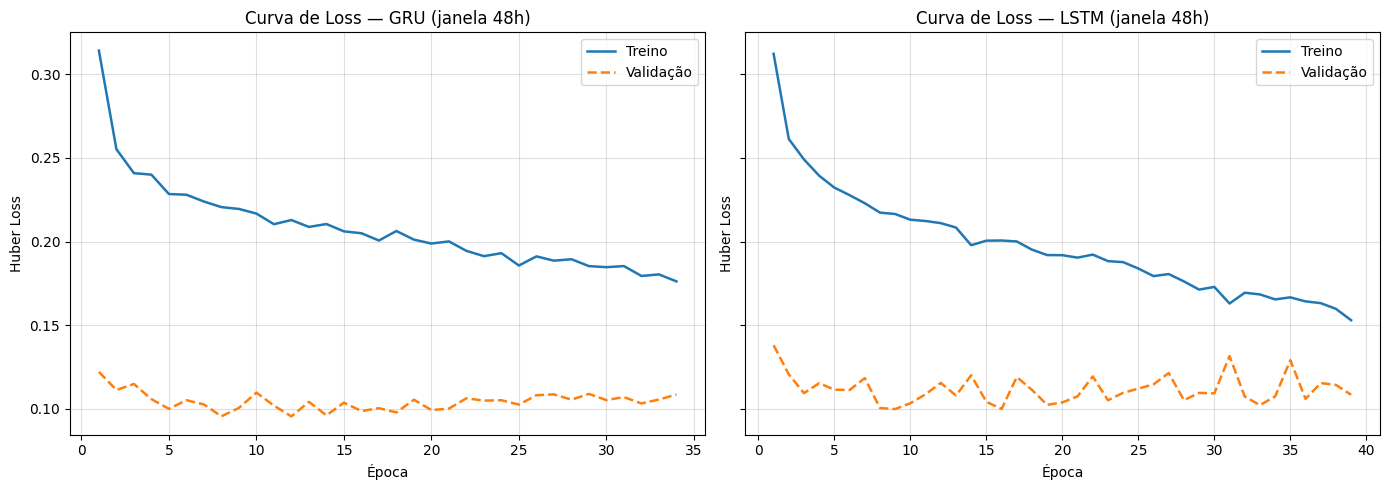

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (nome_modelo, _) in zip(axes, CONSTRUTORES_MODELOS.items()):
    hist_df = pd.DataFrame(historicos[nome_modelo].history)
    epochs  = np.arange(1, len(hist_df) + 1)

    ax.plot(epochs, hist_df["loss"],     linewidth=1.8, label="Treino")
    ax.plot(epochs, hist_df["val_loss"], linewidth=1.8, linestyle="--", label="Validação")
    ax.set_title(f"Curva de Loss — {nome_modelo} (janela 48h)", fontsize=12)
    ax.set_xlabel("Época")
    ax.set_ylabel("Huber Loss")
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


As curvas de loss mostram que tanto a GRU quanto a LSTM aprenderam ao longo do treinamento, com redução progressiva da perda no treino e estabilidade na validação. A validação permaneceu abaixo da curva de treino, o que não indica overfitting clássico.

Essa diferença pode ocorrer porque, durante o treino, há regularização e Dropout ativos, tornando o aprendizado mais restrito. Já na validação, o modelo é avaliado sem o efeito aleatório do Dropout. Além disso, o bloco de validação cobre apenas uma semana específica, que pode ser mais fácil que a média do treino. A GRU apresentou melhor val_mae e também melhor desempenho final no teste.

No geral, as curvas indicam treinamento controlado. O principal desafio continua sendo melhorar a previsão de variações bruscas e picos de consumo.

## 4.5 Previsões: real vs. previsto

Para cada modelo exibimos dois painéis:

- **Treino (últimos 7 dias):** verificação do ajuste do modelo na fase de aprendizado.
- **Teste (semana de teste, ~163 h):** avaliação do desempenho em dados nunca vistos.

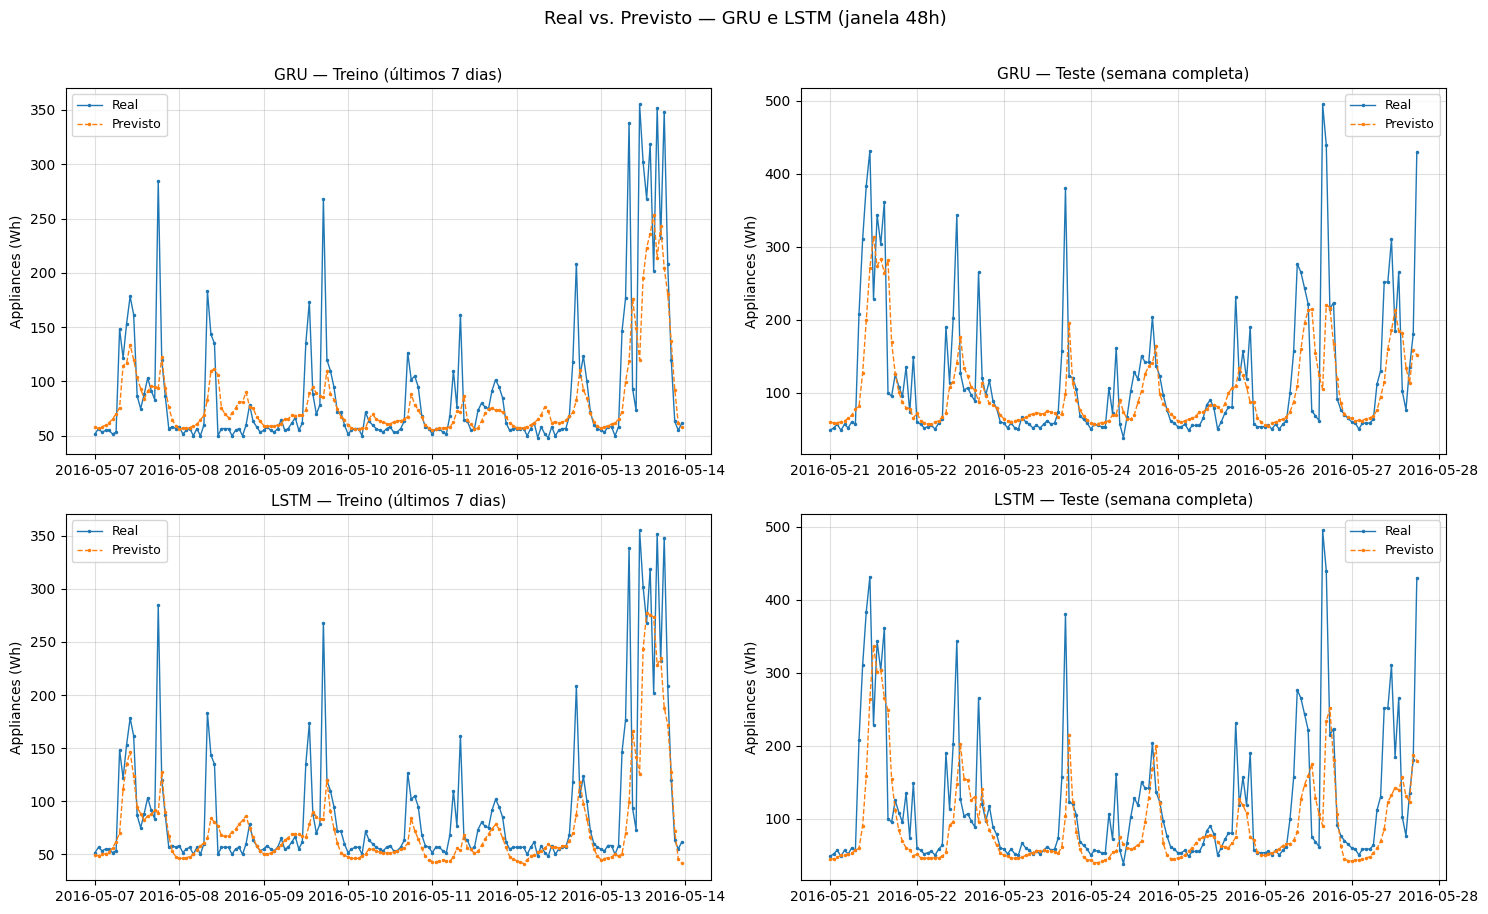

In [ ]:
N_TREINO_VIS = 168  # últimos 7 dias

fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=False)

for col, nome_modelo in enumerate(CONSTRUTORES_MODELOS.keys()):
    info = previsoes_curvas[nome_modelo]

    # Treino
    ax_tr = axes[col, 0]
    idx_tr = info["train"]["index"]
    yr_tr  = info["train"]["y_real"]
    yp_tr  = info["train"]["y_pred"]
    n = min(N_TREINO_VIS, len(yr_tr))
    ax_tr.plot(idx_tr[-n:], yr_tr[-n:], linewidth=1, marker=".", markersize=3, label="Real")
    ax_tr.plot(idx_tr[-n:], yp_tr[-n:], linewidth=1, marker=".", markersize=3,
               linestyle="--", label="Previsto")
    ax_tr.set_title(f"{nome_modelo} — Treino (últimos 7 dias)", fontsize=11)
    ax_tr.set_ylabel("Appliances (Wh)")
    ax_tr.legend(fontsize=9)
    ax_tr.grid(True, alpha=0.4)

    # Teste
    ax_te = axes[col, 1]
    idx_te = info["test"]["index"]
    yr_te  = info["test"]["y_real"]
    yp_te  = info["test"]["y_pred"]
    ax_te.plot(idx_te, yr_te, linewidth=1, marker=".", markersize=3, label="Real")
    ax_te.plot(idx_te, yp_te, linewidth=1, marker=".", markersize=3,
               linestyle="--", label="Previsto")
    ax_te.set_title(f"{nome_modelo} — Teste (semana completa)", fontsize=11)
    ax_te.set_ylabel("Appliances (Wh)")
    ax_te.legend(fontsize=9)
    ax_te.grid(True, alpha=0.4)

plt.suptitle("Real vs. Previsto — GRU e LSTM (janela 48h)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


Os gráficos de real vs. previsto reforçam os resultados observados nas métricas. A GRU e a LSTM conseguem acompanhar o comportamento geral da série, principalmente nos períodos de consumo médio e nos padrões diários mais recorrentes.

Ao mesmo tempo, permanece a dificuldade já observada na análise dos picos: os modelos tendem a suavizar as previsões e subestimar os valores mais altos. A GRU apresentou melhor desempenho global no teste, mas os gráficos mostram que ainda há perda de precisão em eventos extremos.

Assim, a análise visual confirma que o modelo aprende a dinâmica principal da série, mas ainda tem limitação para capturar aumentos bruscos de consumo.

# 5. Conclusão

Selecionamos a melhor configuração pelo menor **MAE no teste** e consolidamos todas as métricas relevantes em uma tabela de resumo.


In [ ]:
df_gap = (
    df_resultados
    .pivot_table(
        index=["Modelo", "Janela"],
        columns="Dataset",
        values="MAE",
        aggfunc="first"
    )
    .reset_index()
)

df_gap["Gap Val vs Treino (%)"] = (
    (df_gap["Validação"] - df_gap["Treino"]) / df_gap["Treino"]
) * 100

df_gap["Gap Teste vs Val (%)"] = (
    (df_gap["Teste"] - df_gap["Validação"]) / df_gap["Validação"]
) * 100


def diagnosticar_gap(row):
    if row["Gap Val vs Treino (%)"] > 30:
        return "Possível overfitting"
    elif row["Gap Teste vs Val (%)"] > 50:
        return "Teste mais difícil / possível mudança de regime"
    else:
        return "Generalização estável"


df_gap["Diagnóstico"] = df_gap.apply(diagnosticar_gap, axis=1)

display(df_gap.round(4))

Dataset,Modelo,Janela,Treino,Validação,Teste,Gap Val vs Treino (%),Gap Teste vs Val (%),Diagnóstico
0,GRU,48h,29.8788,20.0505,39.9177,-32.8938,99.0853,Teste mais difícil / possível mudança de regime
1,LSTM,48h,28.2758,20.5879,44.8456,-27.1890,117.8254,Teste mais difícil / possível mudança de regime


,Modelo,Janela,MAE teste (Wh),RMSE teste (Wh),R² teste,MAPE teste (%),MAE decil superior (Wh),N decil superior,Gap Val vs Treino (%),Gap Teste vs Val (%),Diagnóstico
0,GRU,48h,39.9177,72.565,0.3952,27.3579,165.1569,18,-32.8938,99.0853,Teste mais difícil / possível mudança de regime


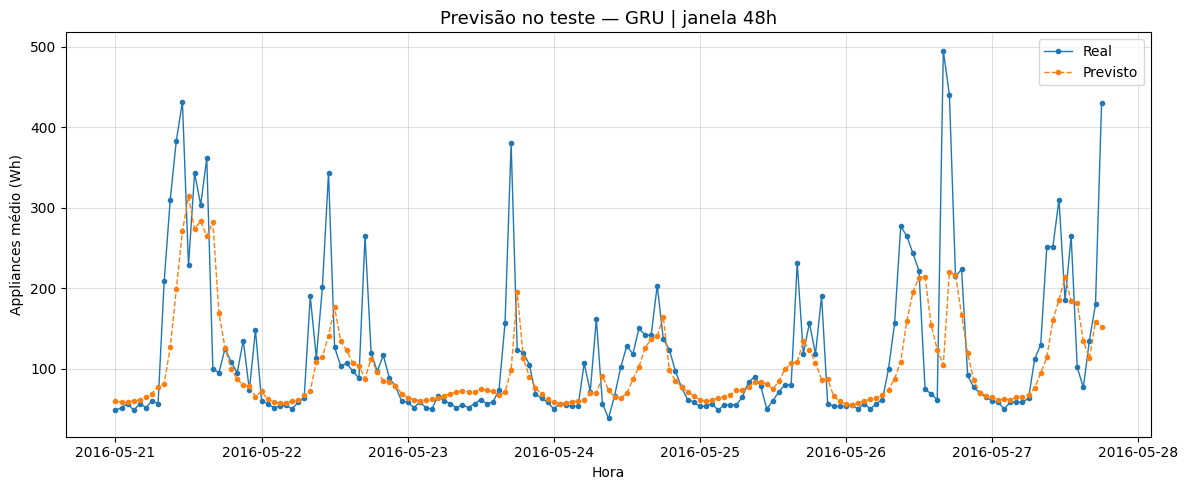

In [ ]:
melhor_linha = df_ranking_teste.iloc[0]
melhor_modelo = str(melhor_linha["Modelo"])

linha_decil = df_decil[df_decil["Modelo"].astype(str) == melhor_modelo].copy()
linha_gap   = df_gap[df_gap["Modelo"].astype(str) == melhor_modelo].copy()

resumo_final = pd.DataFrame([{
    "Modelo":                  melhor_modelo,
    "Janela":                  "48h",
    "MAE teste (Wh)":          melhor_linha["MAE"],
    "RMSE teste (Wh)":         melhor_linha["RMSE"],
    "R² teste":                melhor_linha["R²"],
    "MAPE teste (%)":          melhor_linha["MAPE (%)"],
    "MAE decil superior (Wh)": linha_decil["MAE decil superior"].iloc[0] if len(linha_decil) else np.nan,
    "N decil superior":        int(linha_decil["N decil superior"].iloc[0]) if len(linha_decil) else np.nan,
    "Gap Val vs Treino (%)":   linha_gap["Gap Val vs Treino (%)"].iloc[0] if len(linha_gap) else np.nan,
    "Gap Teste vs Val (%)":    linha_gap["Gap Teste vs Val (%)"].iloc[0] if len(linha_gap) else np.nan,
    "Diagnóstico":             linha_gap["Diagnóstico"].iloc[0] if len(linha_gap) else "",
}])

display(resumo_final.round(4))

# Gráfico final — previsão do modelo vencedor no teste.
info_pred = previsoes_teste[melhor_modelo]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(info_pred["index"], info_pred["y_real"], marker=".", linewidth=1, label="Real")
ax.plot(info_pred["index"], info_pred["y_pred"], marker=".", linewidth=1,
        linestyle="--", label="Previsto")
ax.set_title(f"Previsão no teste — {melhor_modelo} | janela 48h", fontsize=13)
ax.set_ylabel("Appliances médio (Wh)")
ax.set_xlabel("Hora")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


A GRU foi selecionada como modelo final por apresentar o menor MAE no conjunto de teste. O resumo final também indica menor RMSE, maior R² e menor MAPE em relação à LSTM, confirmando sua vantagem global neste experimento.

O diagnóstico de generalização mostra que o teste foi mais difícil que a validação, com gap de aproximadamente 99,09%. Isso sugere possível mudança de regime ou maior instabilidade na semana de teste, e não um caso clássico de overfitting.

Assim, a GRU é adequada para prever o comportamento médio da série, mas seu principal limite permanece na antecipação de picos de consumo.

A partir dos experimentos, a GRU apresentou o melhor desempenho no conjunto de teste, com MAE de 39,92 Wh, RMSE de 72,57 Wh e R² de 0,3952. A LSTM obteve MAE de 44,85 Wh, RMSE de 77,75 Wh e R² de 0,3058, indicando que ambas as arquiteturas conseguiram capturar parte dos padrões temporais relevantes da série, mas com vantagem global para a GRU.

A janela temporal adotada foi de 48 horas, escolhida por capturar dois ciclos diários completos e por apresentar melhor desempenho após os testes com diferentes configurações. Também foram testadas abordagens anteriores, incluindo RNNs, GRUs, LSTMs e modelos estatísticos como ARIMA e SARIMA, usados como base inicial de comparação. Ao longo dos experimentos, os resultados e a análise de overfitting orientaram os ajustes de pré-processamento, regularização e escolha da arquitetura final.

A escolha da GRU se justifica pelo menor erro médio absoluto no teste, menor RMSE, maior R² e melhor MAPE, de 27,36%. Os resultados não indicam overfitting clássico, já que a validação não apresentou piora acentuada em relação ao treino. O maior erro no teste sugere uma semana mais difícil ou uma possível mudança de regime, e não necessariamente memorização dos dados de treinamento.

Mesmo com a vantagem da GRU, os picos de consumo continuam sendo o principal desafio. No decil superior, o erro ainda foi elevado, com MAE de 165,16 Wh, mostrando que o modelo acompanha melhor o comportamento médio da série do que eventos extremos. Assim, conclui-se que a GRU foi a arquitetura mais adequada dentro do critério principal do trabalho, com desempenho coerente diante da complexidade, da sazonalidade e da variabilidade presentes em séries de consumo residencial.

# Referências

REFERÊNCIAS:

[1] https://towardsdatascience.com/cyclical-encoding-an-alternative-to-one-hot-encoding-for-time-series-features-4db46248ebba/